# Multilayer Perceptron on MNIST: Learn from the Mistakes

## Goal

Train a fully connected neural network for handwritten-digit classification,
evaluate it on held-out data, and inspect the confusion matrix and highest-confidence
mistakes instead of reporting accuracy alone.

## Setup

Install `requirements-course-demos.txt`. MNIST is downloaded by `torchvision` into
ignored `data/` on first run. No trained model is committed.

In [1]:
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(min(4, os.cpu_count() or 1))
DEVICE = torch.device("cpu")

print(f"torch={torch.__version__}; device={DEVICE}; seed={SEED}")

torch=2.14.0; device=cpu; seed=42


## Steps

### 1. Load the train and test splits

In [2]:
transform = transforms.ToTensor()
train_dataset = datasets.MNIST("data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST("data", train=False, download=True, transform=transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True,
    generator=torch.Generator().manual_seed(SEED),
    num_workers=0,
)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False, num_workers=0)

print(f"train={len(train_dataset):,}; test={len(test_dataset):,}")

train=60,000; test=10,000


### 2. Define and train the MLP

In [3]:
class DigitMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.10),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.10),
            nn.Linear(128, 10),
        )

    def forward(self, images):
        return self.network(images)


model = DigitMLP().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
history = []

for epoch in range(5):
    model.train()
    train_loss = 0.0
    train_correct = 0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        logits = model(images)
        loss = criterion(logits, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(images)
        train_correct += (logits.argmax(dim=1) == labels).sum().item()

    model.eval()
    test_correct = 0
    with torch.no_grad():
        for images, labels in test_loader:
            logits = model(images.to(DEVICE))
            test_correct += (logits.argmax(dim=1).cpu() == labels).sum().item()

    history.append(
        {
            "epoch": epoch + 1,
            "train_loss": train_loss / len(train_dataset),
            "train_accuracy": train_correct / len(train_dataset),
            "test_accuracy": test_correct / len(test_dataset),
        }
    )

history_frame = pd.DataFrame(history)
history_frame.style.format({"train_loss": "{:.4f}", "train_accuracy": "{:.2%}", "test_accuracy": "{:.2%}"})

,epoch,train_loss,train_accuracy,test_accuracy
0,1,0.4696,86.56%,94.29%
1,2,0.1789,94.67%,95.68%
2,3,0.1270,96.23%,96.95%
3,4,0.0954,97.08%,97.13%
4,5,0.0772,97.65%,97.23%


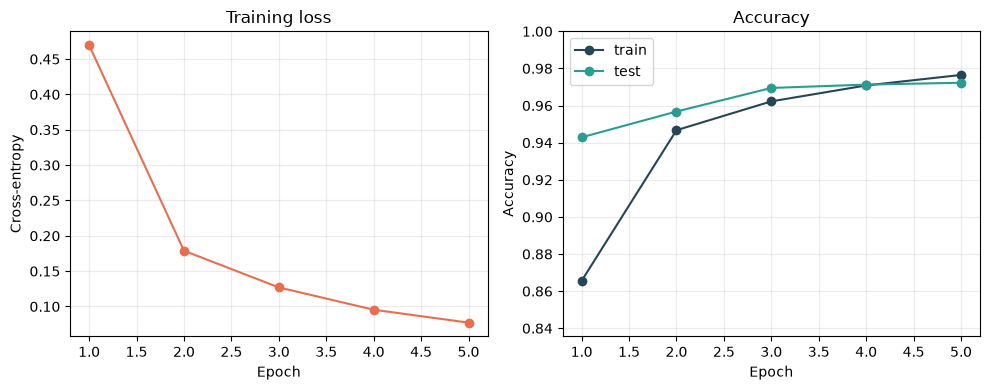

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(history_frame["epoch"], history_frame["train_loss"], marker="o", color="#e76f51")
axes[0].set(xlabel="Epoch", ylabel="Cross-entropy", title="Training loss")
axes[1].plot(history_frame["epoch"], history_frame["train_accuracy"], marker="o", label="train", color="#264653")
axes[1].plot(history_frame["epoch"], history_frame["test_accuracy"], marker="o", label="test", color="#2a9d8f")
accuracy_floor = max(0.0, history_frame[["train_accuracy", "test_accuracy"]].to_numpy().min() - 0.03)
axes[1].set(xlabel="Epoch", ylabel="Accuracy", title="Accuracy", ylim=(accuracy_floor, 1.0))
axes[1].legend()
for axis in axes:
    axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### 3. Evaluate the held-out predictions

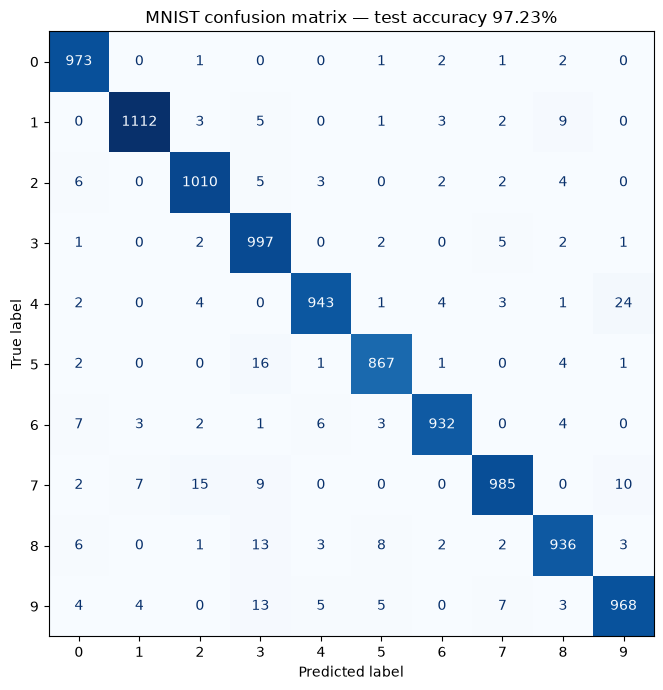

In [5]:
model.eval()
all_probabilities = []
all_predictions = []
all_labels = []
all_images = []

with torch.no_grad():
    for images, labels in test_loader:
        probabilities = torch.softmax(model(images.to(DEVICE)), dim=1).cpu()
        all_probabilities.append(probabilities)
        all_predictions.append(probabilities.argmax(dim=1))
        all_labels.append(labels)
        all_images.append(images)

all_probabilities = torch.cat(all_probabilities)
all_predictions = torch.cat(all_predictions)
all_labels = torch.cat(all_labels)
all_images = torch.cat(all_images)
test_accuracy = (all_predictions == all_labels).float().mean().item()

matrix = confusion_matrix(all_labels.numpy(), all_predictions.numpy(), labels=range(10))
fig, ax = plt.subplots(figsize=(7, 7))
ConfusionMatrixDisplay(matrix, display_labels=range(10)).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"MNIST confusion matrix — test accuracy {test_accuracy:.2%}")
plt.tight_layout()
plt.show()

### 4. Inspect the model's most confident mistakes

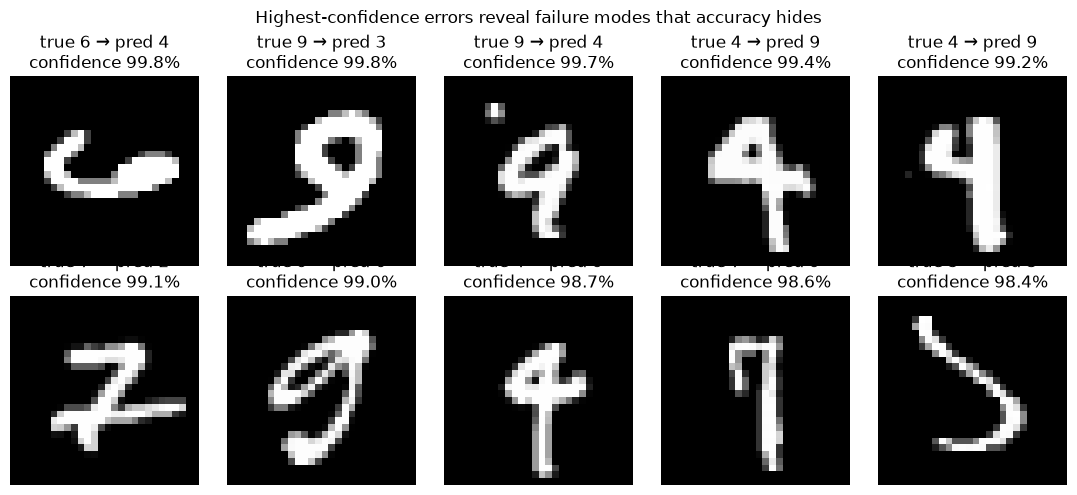

misclassified=277 of 10,000


In [6]:
mistake_indices = torch.where(all_predictions != all_labels)[0]
mistake_confidences = all_probabilities[mistake_indices].max(dim=1).values
order = torch.argsort(mistake_confidences, descending=True)
selected_indices = mistake_indices[order[:10]]

fig, axes = plt.subplots(2, 5, figsize=(11, 5))
for axis, index in zip(axes.flat, selected_indices):
    predicted = all_predictions[index].item()
    actual = all_labels[index].item()
    confidence = all_probabilities[index, predicted].item()
    axis.imshow(all_images[index].squeeze(), cmap="gray")
    axis.set_title(f"true {actual} → pred {predicted}" + chr(10) + f"confidence {confidence:.1%}")
    axis.axis("off")
fig.suptitle("Highest-confidence errors reveal failure modes that accuracy hides")
plt.tight_layout()
plt.show()

print(f"misclassified={len(mistake_indices):,} of {len(test_dataset):,}")

## Checks

In [7]:
assert history_frame["train_loss"].iloc[-1] < history_frame["train_loss"].iloc[0]
assert test_accuracy > 0.97
assert all_probabilities.shape == (10_000, 10)
assert torch.allclose(all_probabilities.sum(dim=1), torch.ones(10_000), atol=1e-5)
assert len(mistake_indices) > 0

print(f"Checks passed: held-out accuracy={test_accuracy:.2%}; probabilities are normalized.")

Checks passed: held-out accuracy=97.23%; probabilities are normalized.


## Next Steps

- Compare the MLP with a convolutional model that preserves image locality.
- Break accuracy down by digit and inspect recurring confusion pairs.
- Calibrate the probabilities before interpreting confidence operationally.
- Test rotated, shifted, noisy, or handwritten-out-of-distribution digits.

The MLP performs well on ordinary MNIST, but its confident errors show why a
single headline metric is never a complete model evaluation.